# 06_特征选择方法-L2 正则化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这篇文章咱们来讲解特征选择方法中的 L2 正则化\~

在机器学习里，我们常常会有一大堆特征（也叫“变量”、“属性”），比如：

想预测一个人是否会生病，可能有年龄、体重、饮食习惯、锻炼频率、睡眠时间、基因信息……几十上百个特征！

**特征选择**的目的就是：从这些一大堆特征里，找出那些对最终结果最有用的，扔掉没啥用的，让模型更简单、运行更快、不容易过拟合。

### L2 正则化是啥？

L2 正则化（也叫 Ridge Regression 岭回归）是一种防止模型“过拟合”的方法。

- 它会在模型的“损失函数”后面，加上一项**惩罚项**（也叫“正则项”）。
- 这个惩罚项跟模型里的参数有关，它会鼓励这些参数尽量“小一点”。

模型就像学生在做题，如果你总是把所有细节都记下来（即每个特征都用得很复杂），你可能考得很好，但换一套题就懵了（这就是过拟合）。

### L2 正则化怎么用在特征选择？

严格来说，**L2 正则化不是直接做特征选择的工具**，但它有一个“隐形的特征选择效果”：

- 它不会直接把某个特征“完全删掉”（不像 L1 正则化那样能让某些特征系数变成0），
- 但它会让**不重要的特征的系数变得很小**，也就是对结果没啥贡献。
- 最终你可以根据系数的大小来判断哪些特征“几乎没用”，然后考虑删掉它们。

所以，L2 正则化虽然不会让某个特征**彻底归零**，但它会**压缩不重要特征的权重**，达到“变相筛选特征”的目的。

## 原理详解

我们从一个简单的线性回归模型开始：

给定样本数据集：


$$
\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}
$$


其中：

- $x^{(i)} = [x^{(i)}_1, x^{(i)}_2, ..., x^{(i)}_n]$ 是第 $i$ 个样本的输入特征向量（共 $n$ 个特征），
- $y^{(i)}$ 是对应的输出（标签），
- $m$ 是样本数量。

我们希望学到一个线性函数来预测输出：


$$
\hat{y}^{(i)} = w_1 x_1^{(i)} + w_2 x_2^{(i)} + \cdots + w_n x_n^{(i)} + b = \mathbf{w}^\top \mathbf{x}^{(i)} + b
$$


### 损失函数：普通最小二乘（OLS）

最小二乘法的目标是最小化预测值和真实值的误差平方和：


$$
J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2= \frac{1}{2m} \sum_{i=1}^{m} \left( \mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)} \right)^2
$$


这个优化目标在参数过多（特征过多）或样本过少时容易过拟合。

### L2 正则化的引入

为了解决过拟合，我们在损失函数中加入一个**惩罚项**，限制参数的大小。这个惩罚项就是 **L2 正则化项**：

**L2 正则化目标函数（带惩罚项）：**


$$
J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)} \right)^2 + \frac{\lambda}{2} \|\mathbf{w}\|_2^2
$$


其中：

- $\|\mathbf{w}\|_2^2 = \sum_{j=1}^{n} w_j^2$，表示所有参数的平方和。
- $\lambda \ge 0$ 是正则化强度，越大对参数的惩罚越强。
- $b$（偏置项）通常**不参与惩罚**。

### 为什么 L2 正则化有效？

**优化目标是“两难平衡”：**

- 拟合训练数据（误差要小）；
- 控制模型复杂度（参数要小）；

在数学上，就是最小化：


$$
\text{总损失} = \text{平方误差} + \lambda \cdot \text{参数平方和}
$$


我们以矩阵形式简化推导。

### L2 正则化的矩阵形式和解析解（Ridge 解）

令：

- 训练数据矩阵 $X \in \mathbb{R}^{m \times n}$，每行是一个样本；
- 标签向量 $\mathbf{y} \in \mathbb{R}^m$；
- 参数向量 $\mathbf{w} \in \mathbb{R}^n$；
- 假设 $b = 0$（或者已经将数据中心化，即均值为0）；

#### OLS 损失函数（矩阵形式）：


$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2
$$


#### 加上 L2 正则化后的损失函数：


$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2 + \frac{\lambda}{2} \| \mathbf{w} \|^2
$$


对 $J(\mathbf{w})$ 求导并设为0，得到解析解：


$$
\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} X^\top (X \mathbf{w} - \mathbf{y}) + \lambda \mathbf{w} = 0
$$


整理得：


$$
(X^\top X + m\lambda I)\mathbf{w} = X^\top \mathbf{y}
$$


即：


$$
\boxed{\mathbf{w}_{\text{ridge}} = (X^\top X + m\lambda I)^{-1} X^\top \mathbf{y}}
$$


这是 L2 正则化的解析解，也叫 Ridge 回归解。

### 算法流程（梯度下降视角）

对于不能解析解的情况（如数据太大或用于非线性模型），使用**梯度下降**求解。

**梯度下降的基本流程：**

1. 初始化权重 $\mathbf{w}$，设初值（如0）；
2. 重复直到收敛：

   - 计算梯度：$\nabla_{\mathbf{w}} = \frac{1}{m} X^\top (X\mathbf{w} - \mathbf{y}) + \lambda \mathbf{w}$
   - 更新权重：$\mathbf{w} := \mathbf{w} - \alpha \cdot \nabla_{\mathbf{w}}$
   - 其中 $\alpha$ 是学习率。

### 特征选择角度下的解读

虽然 **L2 正则化不会把特征系数直接压到 0（即不做显式删除）**，但它确实会：

- 把“对结果影响小”的特征的权重 $w_j$ 压得非常小；
- 对“冗余或共线”的特征起到平衡作用（比如两个特征高度相关，L2 会让它们的权重更均衡）；
- 实际上起到“软特征选择”的作用。

与之相对的是 **L1 正则化（Lasso）**，它的正则项是 $\|\mathbf{w}\|_1 = \sum |w_j|$，它可以将某些 $w_j$ 压到**恰好为0**，实现“硬特征选择”。

## 完整案例

使用 **L2 正则化** 进行特征选择和预测。

**案例目标**：

- 使用岭回归预测加州房价中位数（`MedHouseVal`）。
- 利用 L2 正则化控制模型复杂度，提高泛化能力。
- 通过可视化分析监督模型训练与调参过程。
- 展示如何优化正则化参数(alpha)并体现其对特征系数分布的影响。

### 数据集

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 加载数据集
housing = load_local_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

- 加州数据包含 8 个特征，如 `MedInc`（收入中位数）、`HouseAge`（房龄）、`AveRooms`（平均房间数）等，目标是每户平均房价中位数。
- 使用 `pandas.DataFrame` 方便后续探索与特征处理。

### 数据基本检查与探索性分析（EDA）

**数据形状与描述统计**：

In [3]:
print(X.shape, y.shape)
print(X.describe().T)

(2500, 8) (2500,)
             count         mean          std         min         25%  \
MedInc      2500.0     3.812997     1.874065    0.499900    2.518075   
HouseAge    2500.0    28.922400    12.622207    1.000000   18.000000   
AveRooms    2500.0     5.460225     3.412016    0.888889    4.410806   
AveBedrms   2500.0     1.108314     0.762000    0.500000    1.007678   
Population  2500.0  1461.117600  1214.838324    5.000000  786.000000   
AveOccup    2500.0     2.960328     1.025841    1.161290    2.416954   
Latitude    2500.0    35.599892     2.132465   32.560000   33.930000   
Longitude   2500.0  -119.533992     1.998028 -124.190000 -121.760000   

                    50%          75%           max  
MedInc         3.494000     4.665725     15.000100  
HouseAge      30.000000    38.000000     52.000000  
AveRooms       5.221315     6.008206    132.533333  
AveBedrms      1.050422     1.101615     34.066667  
Population  1162.000000  1760.500000  16122.000000  
AveOccup       

查看样本数、特征数、变量分布范围（均值、中位数、方差等）。了解特征量纲差异，有助于后续标准化设计。

**目标变量分布**：

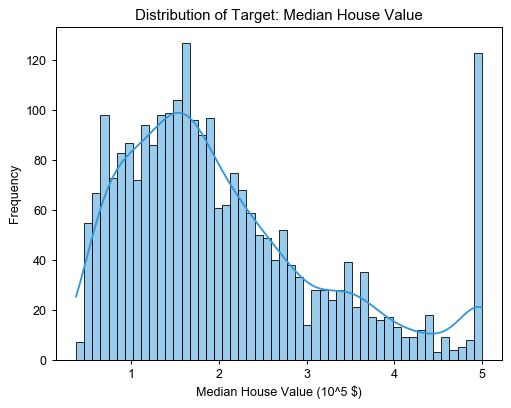

In [4]:
sns.histplot(y, bins=50, kde=True, color='#3498db')
plt.title("Distribution of Target: Median House Value")
plt.xlabel("Median House Value (10^5 $)")
plt.ylabel("Frequency")
plt.show()

了解目标变量是否偏态分布。通过图可判断是否需要转换目标（如 log 转换）来平滑模型误差。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

### 特征之间与目标的 Correlation Heatmap

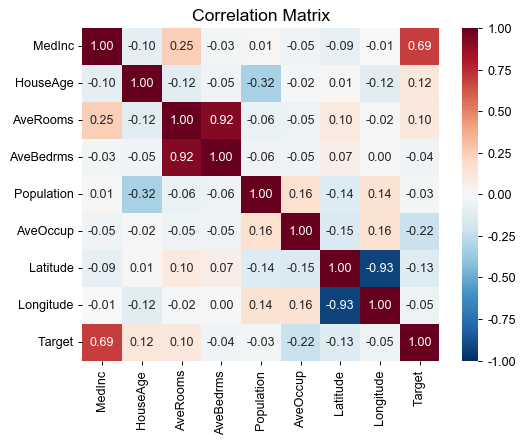

In [5]:
df = X.copy(); df['Target'] = y
corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

- 较强正相关的特征（如收入、房间数）对预测重要，负相关特征（如居民密度）则可能成为噪声。
- 揭示共线性问题，为正则化提供背景理由。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

### 数据预处理

**分割训练集和测试集**：

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

训练集大小: (1750, 8)
测试集大小: (750, 8)


**特征标准化**：

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

岭回归对特征缩放敏感，目标是对所有系数施加统一惩罚。标准化后效果更稳定。

### 初始模型：岭回归（alpha=1）

In [8]:
ridge = Ridge(alpha=1.0, random_state=0)
ridge.fit(X_train_scaled, y_train)

y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"训练集 MSE: {mse_train:.4f}, R2: {r2_train:.4f}")
print(f"测试集  MSE: {mse_test:.4f}, R2: {r2_test:.4f}")

训练集 MSE: 0.4973, R2: 0.6425
测试集  MSE: 0.6264, R2: 0.5050


MSE 和 R² 分别衡量模型误差和拟合程度。初步判断是否过拟合或欠拟合。

### 可视化特征系数

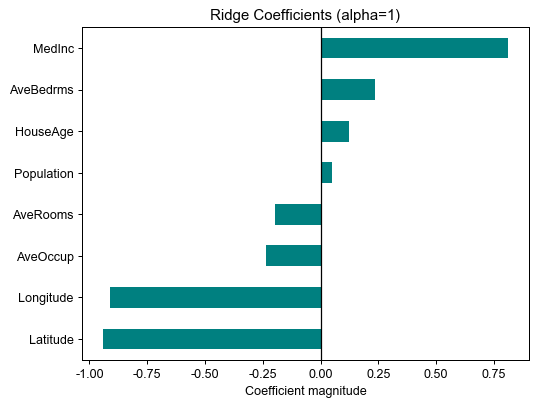

In [9]:
coef = pd.Series(ridge.coef_, index=X.columns).sort_values()
coef.plot(kind='barh', color='teal')
plt.axvline(0, color='black', linewidth=1)
plt.title("Ridge Coefficients (alpha=1)")
plt.xlabel("Coefficient magnitude")
plt.show()

可视化各特征在模型中的线性权重。体现哪些特征被赋予更高影响力，哪些被压缩。

![原文参考图，当前结果见代码输出](attachments/img_024.png)

### 调参优化：网格搜索交叉验证选择最佳 alpha

In [10]:
alphas = np.logspace(-3, 3, 50)
param_grid = {'alpha': alphas}

grid = GridSearchCV(Ridge(random_state=0), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1, error_score='raise')
grid.fit(X_train_scaled, y_train)

best_alpha = grid.best_params_['alpha']
print("最佳 alpha:", best_alpha)

best_ridge = grid.best_estimator_
y_test_pred_best = best_ridge.predict(X_test_scaled)

mse_test_best = mean_squared_error(y_test, y_test_pred_best)
r2_test_best = r2_score(y_test, y_test_pred_best)

print(f"优化后测试集 MSE: {mse_test_best:.4f}, R2: {r2_test_best:.4f}")

最佳 alpha: 2.6826957952797246
优化后测试集 MSE: 0.6228, R2: 0.5078


通过 5 折交叉验证，寻找使测试 MSE 最小的 alpha，提升模型泛化能力。

### alpha 调整效果可视化

**MSE 随 alpha 变化趋势图**：

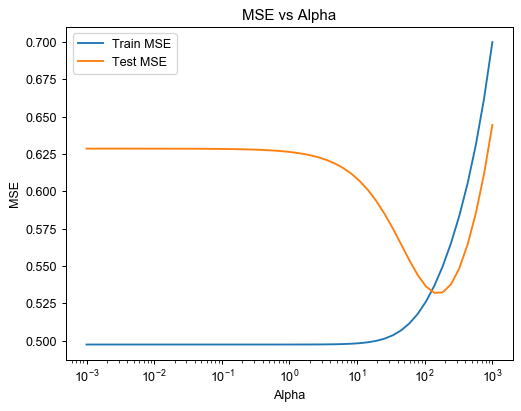

In [11]:
mse_train_list, mse_test_list = [], []
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    mse_train_list.append(mean_squared_error(y_train, model.predict(X_train_scaled)))
    mse_test_list.append(mean_squared_error(y_test, model.predict(X_test_scaled)))
    
plt.plot(alphas, mse_train_list, label='Train MSE')
plt.plot(alphas, mse_test_list, label='Test MSE')
plt.xscale('log'); plt.xlabel('Alpha'); plt.ylabel('MSE')
plt.legend(); plt.title('MSE vs Alpha')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_025.png)

**系数随 alpha 变化趋势图**：

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9870/1549698198.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


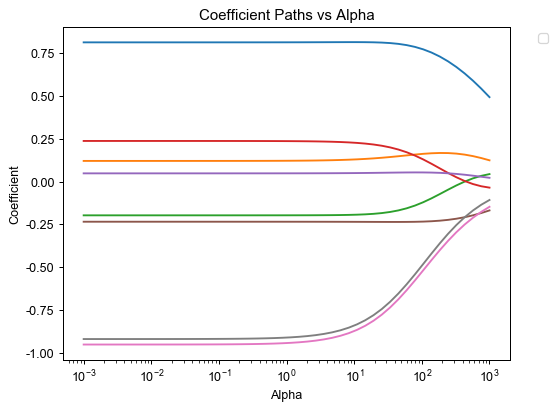

In [12]:
coef_df = pd.DataFrame(index=alphas, columns=X.columns)
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    coef_df.loc[a] = model.coef_

# 绘制 selected features’ coefficient vs alpha
selected = coef_df.columns
plt.plot(alphas, coef_df[selected])
plt.xscale('log')
plt.xlabel('Alpha'); plt.ylabel('Coefficient')
plt.title('Coefficient Paths vs Alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

特征系数被压缩的动态过程，越大惩罚 \~ 越接近 0。

![原文参考图，当前结果见代码输出](attachments/img_026.png)

### 最优 alpha 下的系数可视化

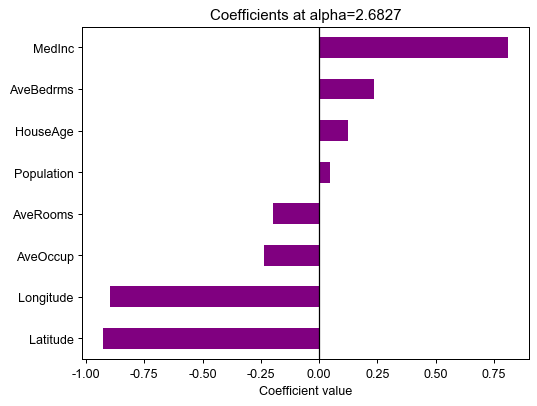

In [13]:
coef_best = pd.Series(best_ridge.coef_, index=X.columns).sort_values()
coef_best.plot(kind='barh', color='purple')
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Coefficients at alpha={best_alpha:.4f}")
plt.xlabel("Coefficient value")
plt.show()

- 展示调参后每个特征的最终权重分布。
- 对比初始模型，可以直观感受正则化压缩的作用。

![原文参考图，当前结果见代码输出](attachments/img_027.png)

### 模型评估与可视化输出

**真实值 vs 预测值散点图**：

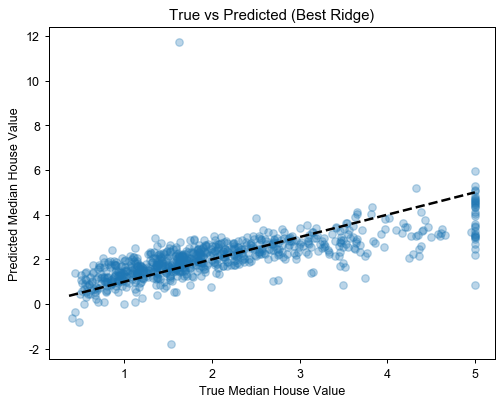

In [14]:
plt.scatter(y_test, y_test_pred_best, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2)
plt.xlabel('True Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('True vs Predicted (Best Ridge)')
plt.show()

理想情况下点应沿对角线分布。散点偏差衡量预测残差。可以进一步计算残差分布。

![原文参考图，当前结果见代码输出](attachments/img_028.png)

**残差分布图**：

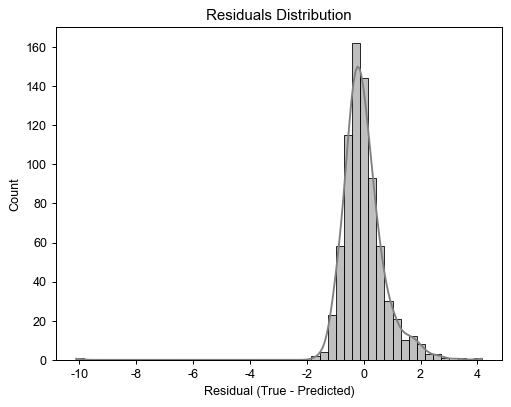

In [15]:
residuals = y_test - y_test_pred_best
sns.histplot(residuals, bins=50, kde=True, color='gray')
plt.title('Residuals Distribution')
plt.xlabel('Residual (True - Predicted)')
plt.show()

正态分布的残差表明模型假设合理，无系统性偏差。若存在偏斜或多峰，可能需进一步特征工程或非线性处理。

![原文参考图，当前结果见代码输出](attachments/img_029.png)

## 模型分析

### 优缺点分析

**优点：**

1. **防止过拟合，提升泛化能力**：L2 正则化通过惩罚参数平方和，使模型在面对高维数据或多重共线性（特征高度相关）时更加稳定，能有效控制模型复杂度。
2. **保留全部特征，做“软特征选择”**：L2 正则化不会直接将特征系数压为 0，而是把对输出贡献小的特征的系数缩小。这在你**不希望舍弃任何信息**时非常重要，尤其适用于解释性强的模型场景。
3. **数学解稳定，解法可解析**：与普通最小二乘法相比，L2 正则化通过矩阵 $(X^TX + \lambda I)$ 的正则化操作，避免了矩阵奇异（无法求逆）的问题，使计算更加稳定。
4. **适用于共线性严重的数据集**：在存在多个相关特征的情况下，L2 正则化比 OLS 更可靠，它会平滑地分摊这些特征的系数。

**缺点：**

1. **不能实现显式特征选择（系数不为零）**：L2 不会将权重压缩为 **0**，不能直接舍弃无用特征。因此无法实现“硬特征选择”（Hard Feature Selection）。
2. **模型解释性差于L1**：因为所有特征都被保留，即使某些特征的系数非常小，也会参与预测，这可能会干扰后续的解释或部署。
3. **不适合稀疏建模需求**：如果你的目标是构建一个具有**较少非零系数**的稀疏模型，L2 并不适合，应该考虑 L1 或 ElasticNet。

### 与其他特征选择方法对比

| 方法 | 正则项形式 | 是否稀疏（系数为0） | 抗多重共线性 | 模型稳定性 | 特征选择方式 | 适合场景 |
|-|-|-|-|-|-|-|
| **L2（Ridge）** | $\sum w_j^2$ | 否 | 强 | 高 | 软选择 | 特征较多但都重要，共线性明显 |
| **L1（Lasso）** | $\sum \| w_j \|$ | 是 | 弱 | 不稳定 | 硬选择 | 特征多，目标是稀疏建模 |
| **ElasticNet** | $\lambda_1 \sum \| w_j \| + \lambda_2 \sum w_j^2$ | 是（部分） | 中等 | 中等 | 混合选择 | 有部分冗余特征，需平衡稳定性与稀疏性 |
| **树模型（RF/XGBoost）特征重要性** | 基于分裂增益 | 是（通过选择） | 强 | 高 | 嵌入式选择 | 非线性关系显著、特征重要性排序 |
| **过滤法（如卡方、方差筛选）** | 不依赖模型 | 是 | 弱 | 弱 | 过滤式选择 | 初步粗筛，辅助建模 |

### 在什么情况下选择 L2 正则化？

**优选 L2 正则化的场景：**

- 特征数量适中，但存在显著的**共线性问题**（如多个变量高度相关）。
- 所有特征都有潜在价值，不希望直接删除特征。
- 你希望模型保持稳定并具备良好的泛化能力。
- 建模目标是**回归预测而非特征压缩**。
- 在解释性要求不高、目标是提升预测性能的场景。

**考虑使用其他特征选择方法的场景：**

- **目标是压缩模型、提高稀疏性**：使用 **L1 正则化（Lasso）**。
- **部分特征对预测影响为零或接近零**：考虑 **ElasticNet**，结合 L1 和 L2。
- **面对非线性数据或高阶特征交互复杂**：考虑 **树模型（如随机森林、XGBoost）特征重要性排序**。
- **快速粗筛、去除低方差或低信息量特征**：使用 **过滤式方法（如方差阈值法、互信息法）**。

### 总结

L2 正则化是一种简单而强大的特征选择策略，尤其适合线性模型中处理特征多样性和多重共线性的场景。它的优雅在于平滑地压缩权重而非直接舍弃特征，适用于那些不希望彻底删除特征但又希望防止模型过拟合的场合。

如果你追求的是“特征压缩”与“模型解释性”，则 L1 正则化或 ElasticNet 更合适。但如果你希望的是“预测稳定性”和“所有特征都保留但影响不均”，L2 正则化是首选方案之一。